In [ ]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
import seaborn as sns
import random
from skimage import filters
from skimage import exposure
import cv2 as cv
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from skimage.feature import hog
import skimage
import warnings
warnings.filterwarnings("ignore")


In [ ]:
cls=["malinois","English_springer","Great_Dane","Blenheim_spaniel"]
dog_images = glob.glob('/Users/yashwanth/Images/*/*')
breeds = glob.glob('/Users/yashwanth/Images/*')
annotations = glob.glob('/Users/yashwanth/Annotation/*/*')
cropped = "./Cropped/"

In [ ]:
def get_bounding_boxes(annot):
    xml = annot
    tree = ET.parse(xml)
    root = tree.getroot()
    objects = root.findall('object')
    bbox = []
    for o in objects:
        bndbox = o.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)
        bbox.append((xmin,ymin,xmax,ymax))
    return bbox

In [ ]:
def get_image(annot):
    img_path = '/Users/yashwanth/Images/'
    file = annot.split('/')
    img_filename = img_path + file[-2]+'/'+file[-1]+'.jpg'
    return img_filename

In [ ]:
import xml.etree.ElementTree as ET
from keras_preprocessing import image
from PIL import Image
from pathlib import Path
plt.figure(figsize=(10,6))
for i in range(len(dog_images)):
    bbox = get_bounding_boxes(annotations[i])
    dog = get_image(annotations[i])
    im = Image.open(dog)
    for j in range(len(bbox)):
        im2 = im.crop(bbox[j])
        im2 = im2.resize((128,128), Image.ANTIALIAS)
        new_path = dog.replace('/Users/yashwanth/Images/','/Users/yashwanth/Cropped/')
        new_path = new_path.replace('.jpg','-' + str(j) + '.jpg')
        im2=im2.convert('RGB')
        head, tail = os.path.split(new_path)
        Path(head).mkdir(parents=True, exist_ok=True)
        im2.save(new_path)

<Figure size 1000x600 with 0 Axes>

In [ ]:
cropped=glob.glob('/Users/yashwanth/Cropped/*/*')

In [ ]:
data,clas=[],[]
trash=[]
for i in cropped:
    class_id=i.split('/')[4].split('-')[1]
    match class_id:
        case "malinois":

            data.append(i);
            clas.append(class_id);
        case "English_springer":
            data.append(i);
            clas.append(class_id);
        case "Great_Dane":
            data.append(i);
            clas.append(class_id);

        case "Blenheim_spaniel":
            data.append(i);
            clas.append(class_id);
        case _ :
            trash.append(class_id)





In [ ]:
histograms = []

for img_path in data:
    image = plt.imread(img_path)
    grayscale = rgb2gray(image)
    angle_sobel = angle(filters.sobel_h(grayscale), filters.sobel_v(grayscale))
    hist, _ = exposure.histogram(angle_sobel, nbins=36)
    # Append histogram to the list
    histograms.append(hist)

'malinois'

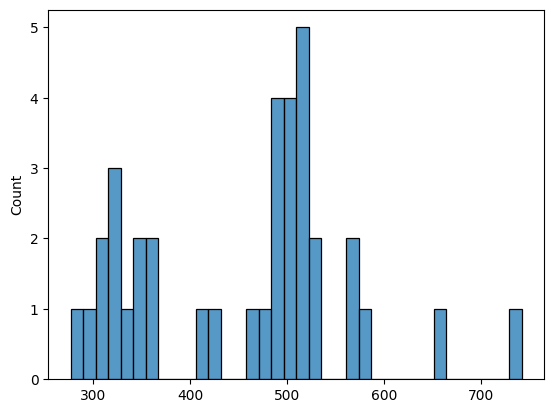

In [ ]:

sns.histplot(histograms[1], bins=36)
clas[1]

In [ ]:
from sklearn.model_selection import train_test_split

# Initialize lists to store training and test data and labels for each class
train_data, test_data = [], []
train_clas, test_clas = [], []

# Iterate over each class
for class_label in set(clas):
    # Get indices of data samples belonging to the current class
    class_indices = [i for i, label in enumerate(clas) if label == class_label]

    # Split indices into training and test sets with 80/20 ratio
    train_indices, test_indices = train_test_split(class_indices, test_size=0.2, random_state=42)

    # Add corresponding data and labels to training and test sets
    train_data.extend([histograms[i] for i in train_indices])
    train_clas.extend([clas[i] for i in train_indices])
    test_data.extend([histograms[i] for i in test_indices])
    test_clas.extend([clas[i] for i in test_indices])

# Verify lengths of training and test sets
print("Training set size:", len(train_data))
print("Test set size:", len(test_data))


Training set size: 550
Test set size: 140


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
train_data_standardized = scaler.fit_transform(train_data)


In [ ]:
# Transform the test data using the means and variances obtained from the training data
test_data_standardized = scaler.transform(test_data)



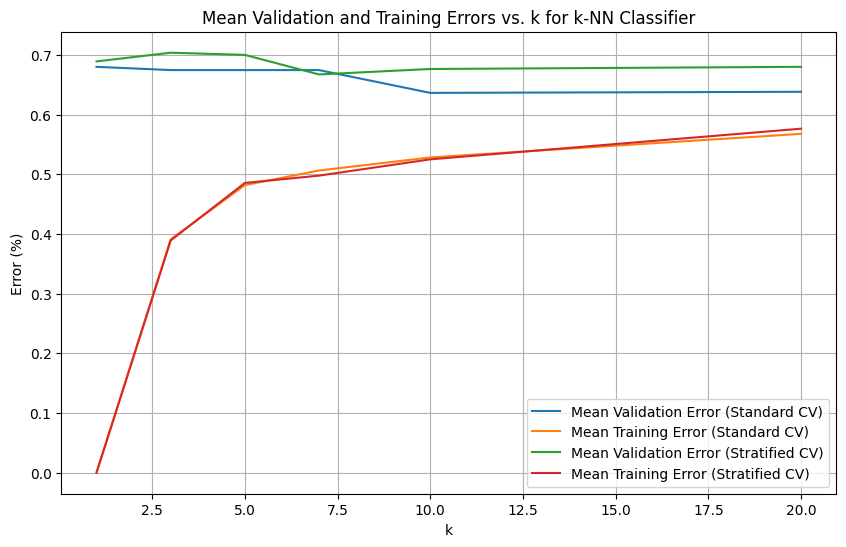

Best k value with lowest mean validation error: 20
Error for the test dataset: 0.6214285714285714


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

# Define k values
k_values = [1, 3, 5, 7, 10, 20]

train_clas = np.array(train_clas)
# Initialize lists to store mean validation and training errors
mean_val_errors_standard = []
mean_train_errors_standard = []
mean_val_errors_stratified = []
mean_train_errors_stratified = []

# Perform standard 5-fold cross-validation for each k value
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for k in k_values:
    val_errors = []
    train_errors = []
    for train_index, val_index in kf.split(train_data_standardized):
        X_train, X_val = train_data_standardized[train_index], train_data_standardized[val_index]
        y_train, y_val = train_clas[train_index], train_clas[val_index]

        # Initialize k-Nearest Neighbor Classifier
        knn = KNeighborsClassifier(n_neighbors=k)

        # Fit the classifier
        knn.fit(X_train, y_train)

        # Calculate validation error
        val_error = 1 - knn.score(X_val, y_val)
        val_errors.append(val_error)

        # Calculate training error
        train_error = 1 - knn.score(X_train, y_train)
        train_errors.append(train_error)

    # Calculate mean validation and training errors for each k value
    mean_val_error = np.mean(val_errors)
    mean_train_error = np.mean(train_errors)

    mean_val_errors_standard.append(mean_val_error)
    mean_train_errors_standard.append(mean_train_error)

# Perform stratified 5-fold cross-validation for each k value
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for k in k_values:
    val_errors = []
    train_errors = []
    best_k = None
    best_val_error = float('inf')
    for train_index, val_index in skf.split(train_data_standardized, train_clas):
        X_train, X_val = train_data_standardized[train_index], train_data_standardized[val_index]
        y_train, y_val = np.array(train_clas)[train_index], np.array(train_clas)[val_index]

        # Initialize k-Nearest Neighbor Classifier
        knn = KNeighborsClassifier(n_neighbors=k)

        # Fit the classifier
        knn.fit(X_train, y_train)

        # Calculate validation error
        val_error = 1 - knn.score(X_val, y_val)
        val_errors.append(val_error)

        # Calculate training error
        train_error = 1 - knn.score(X_train, y_train)
        train_errors.append(train_error)
    mean_val_error = np.mean(val_errors)

    if mean_val_error < best_val_error:
        best_val_error = mean_val_error
        best_k = k

    # Calculate mean validation and training errors for each k value
    mean_val_error = np.mean(val_errors)
    mean_train_error = np.mean(train_errors)

    mean_val_errors_stratified.append(mean_val_error)
    mean_train_errors_stratified.append(mean_train_error)

# Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, mean_val_errors_standard, label='Mean Validation Error (Standard CV)')
plt.plot(k_values, mean_train_errors_standard, label='Mean Training Error (Standard CV)')
plt.plot(k_values, mean_val_errors_stratified, label='Mean Validation Error (Stratified CV)')
plt.plot(k_values, mean_train_errors_stratified, label='Mean Training Error (Stratified CV)')
plt.xlabel('k')
plt.ylabel('Error (%)')
plt.title('Mean Validation and Training Errors vs. k for k-NN Classifier')
plt.legend()
plt.grid(True)
plt.show()


print("Best k value with lowest mean validation error:", best_k)

# Evaluate on test dataset
knn_test = KNeighborsClassifier(n_neighbors=best_k)
knn_test.fit(train_data_standardized, train_clas)
test_error = 1 - knn_test.score(test_data_standardized, test_clas)
print("Error for the test dataset:", test_error)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import LinearSVC
import numpy as np



# Initialize LinearSVC classifier with default parameters
svm_classifier = LinearSVC()

# Initialize StratifiedKFold with 5 folds
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform stratified 5-fold cross-validation
cv_scores = cross_val_score(svm_classifier, train_data_standardized, train_clas, cv=stratified_kfold)

# Display the cross-validation scores
print("Cross-validation scores:", cv_scores)

# Calculate and display the mean and standard deviation of the cross-validation scores
print("Mean cross-validation score:", np.mean(cv_scores))
print("Standard deviation of cross-validation scores:", np.std(cv_scores))


Cross-validation scores: [0.37272727 0.3        0.34545455 0.36363636 0.30909091]
Mean cross-validation score: 0.3381818181818182
Standard deviation of cross-validation scores: 0.028977049910016785


Accuracy: 0.21428571428571427
F1 Score: 0.14934305460621247
Confusion Matrix:
[[13 28  0  0]
 [17 17  0  0]
 [11 22  0  1]
 [17 13  1  0]]


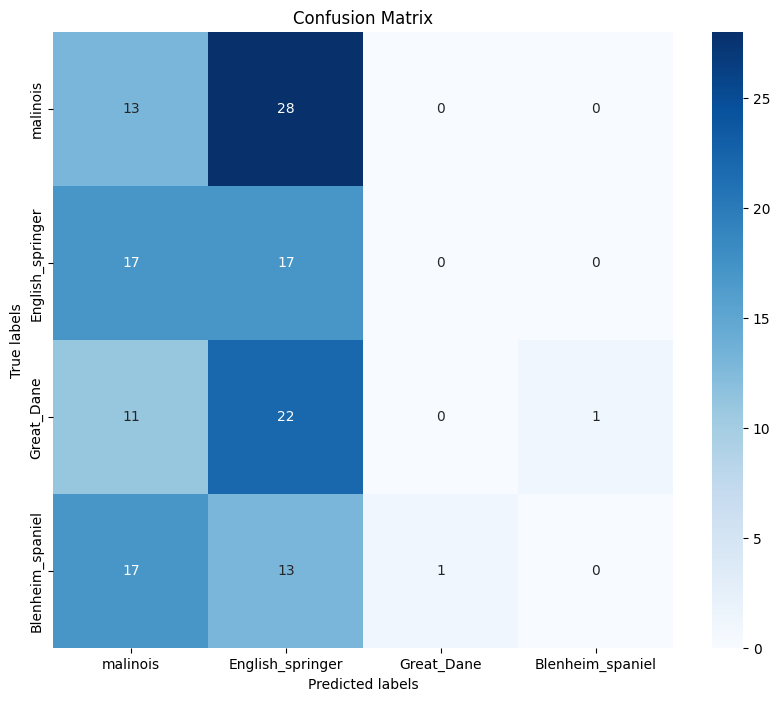

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

svm_classifier.fit(train_data_standardized, train_clas)
y_pred = svm_classifier.predict(test_data)

# Calculate the confusion matrix
conf_matrix = confusion_matrix(test_clas, y_pred)
accuracy = accuracy_score(test_clas, y_pred)
print("Accuracy:", accuracy)

# Calculate F1 score
f1 = f1_score(test_clas, y_pred, average='weighted')
print("F1 Score:", f1)


print("Confusion Matrix:")
print(conf_matrix)

classes = ["malinois", "English_springer", "Great_Dane", "Blenheim_spaniel"]
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Initialize the Random Forest classifier with default parameters
rf_classifier = RandomForestClassifier()

# Initialize StratifiedKFold with 5 folds
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform stratified 5-fold cross-validation
cv_scores = cross_val_score(rf_classifier, train_data_standardized, train_clas, cv=stratified_kfold)

# Display the cross-validation scores
print("Cross-validation scores:", cv_scores)

# Calculate and display the mean and standard deviation of the cross-validation scores
print("Mean cross-validation score:", np.mean(cv_scores))
print("Standard deviation of cross-validation scores:", np.std(cv_scores))


Cross-validation scores: [0.4        0.31818182 0.34545455 0.45454545 0.33636364]
Mean cross-validation score: 0.37090909090909097
Standard deviation of cross-validation scores: 0.0499255644281672


Accuracy: 0.35714285714285715
F1 Score: 0.34981708699848496


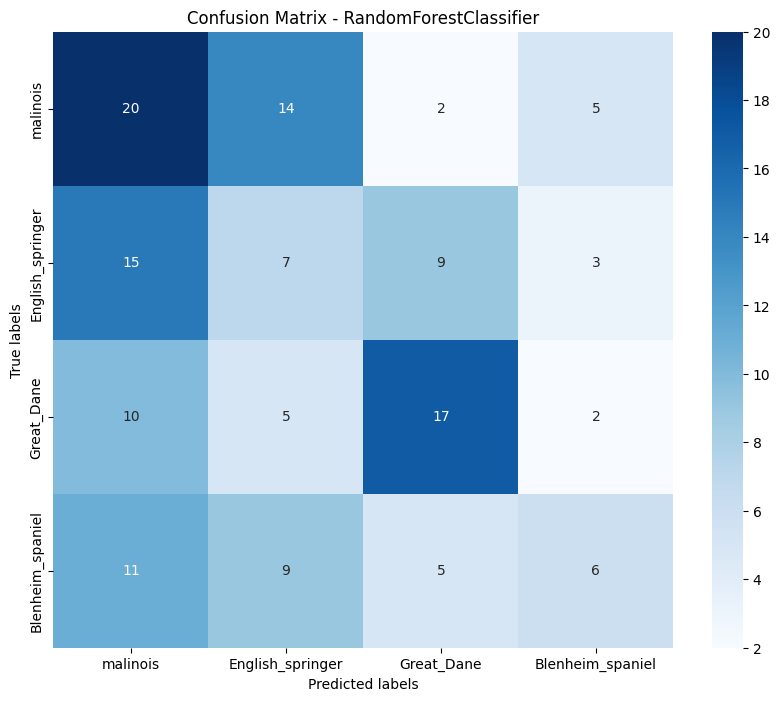

In [ ]:
rf_classifier = RandomForestClassifier()

# Train the classifier
rf_classifier.fit(train_data_standardized, train_clas)

# Make predictions
y_pred = rf_classifier.predict(test_data_standardized)  # Replace test_data_standardized with  actual test data

# Calculate confusion matrix
conf_matrix = confusion_matrix(test_clas, y_pred)  # Replace test_clas with  actual test labels
accuracy = accuracy_score(test_clas, y_pred)
print("Accuracy:", accuracy)

# Calculate F1 score
f1 = f1_score(test_clas, y_pred, average='weighted')
print("F1 Score:", f1)
# Plot confusion matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix - RandomForestClassifier')
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# Initialize the MLPClassifier with specified parameters
mlp_classifier = MLPClassifier(hidden_layer_sizes=(10, 10, 10), random_state=42)

# Initialize StratifiedKFold with 5 folds
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform stratified 5-fold cross-validation
cv_scores = cross_val_score(mlp_classifier, train_data_standardized, train_clas, cv=stratified_kfold)

# Display the cross-validation scores
print("Cross-validation scores:", cv_scores)

# Calculate and display the mean and standard deviation of the cross-validation scores
print("Mean cross-validation score:", np.mean(cv_scores))
print("Standard deviation of cross-validation scores:", np.std(cv_scores))


Cross-validation scores: [0.3        0.25454545 0.31818182 0.30909091 0.31818182]
Mean cross-validation score: 0.29999999999999993
Standard deviation of cross-validation scores: 0.023706190564373276


Accuracy: 0.35714285714285715
F1 Score: 0.34863974097464656


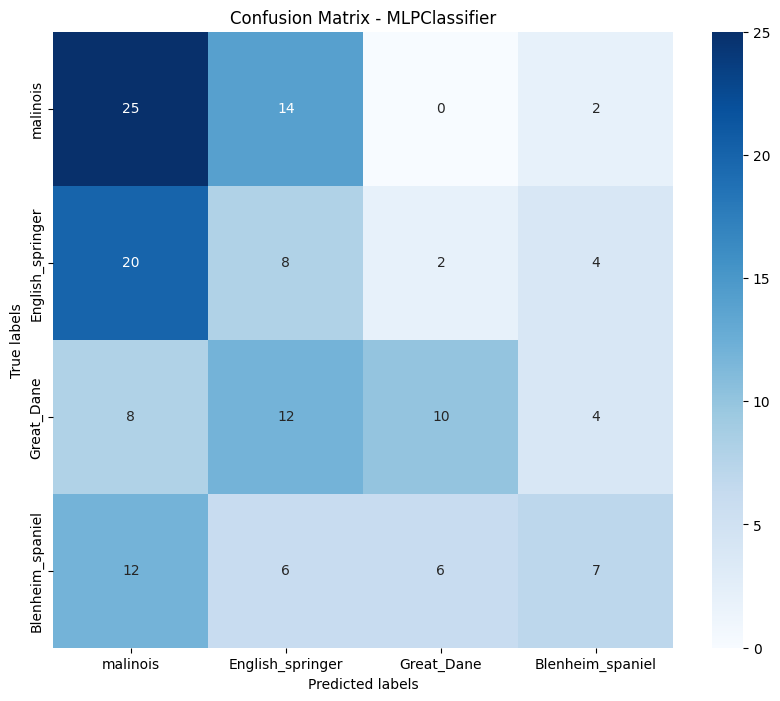

In [ ]:


# Train the MLPClassifier on the entire training data
mlp_classifier.fit(train_data_standardized, train_clas)
# Make predictions on the test data
y_pred = mlp_classifier.predict(test_data_standardized)


accuracy = accuracy_score(test_clas, y_pred)
print("Accuracy:", accuracy)

# Calculate F1 score
f1 = f1_score(test_clas, y_pred, average='weighted')
print("F1 Score:", f1)


# Calculate confusion matrix
conf_matrix = confusion_matrix(test_clas, y_pred)
# Plot confusion matrix as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix - MLPClassifier')
plt.show()


A) By visually comparing (e.g., looking at the color on the diagonal values, etc.) the three confusion
matrices (on the test set), which do you think is the best method? Why?  

-> Neural network and Random Forest, both of them got the same values for sum of diagonal values (i.e. 50).

B) Based on the mean validation accuracies (from the 5-fold cross-validation) for the three methods. Which is the best method?

-> Random Forest is best among the three based on mean cross validation accuracies. (i.e. 0.37090909090909097)

C) Compute the accuracies for the three methods on the test set. Which is the best method?

-> Neural network and Random forest has the same accuracy among the three methods. (i.e. 0.35714285714285715)

D) Compute the F-measure for the three methods on the test set. Which is the best method?

-> Random forest is the best method among three as it has the highest F-measure score. (i.e. 0.34981708699848496)

#References:
https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

https://scikit-learn.org/stable/modules/neural_networks_supervised.html

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html